In [437]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

In [438]:
df = pd.read_csv("Customer-Churn (1).csv")

In [490]:
import pandas

In [491]:
dir(pandas)

['ArrowDtype',
 'BooleanDtype',
 'Categorical',
 'CategoricalDtype',
 'CategoricalIndex',
 'DataFrame',
 'DateOffset',
 'DatetimeIndex',
 'DatetimeTZDtype',
 'ExcelFile',
 'ExcelWriter',
 'Flags',
 'Float32Dtype',
 'Float64Dtype',
 'Grouper',
 'HDFStore',
 'Index',
 'IndexSlice',
 'Int16Dtype',
 'Int32Dtype',
 'Int64Dtype',
 'Int8Dtype',
 'Interval',
 'IntervalDtype',
 'IntervalIndex',
 'MultiIndex',
 'NA',
 'NaT',
 'NamedAgg',
 'Period',
 'PeriodDtype',
 'PeriodIndex',
 'RangeIndex',
 'Series',
 'SparseDtype',
 'StringDtype',
 'Timedelta',
 'TimedeltaIndex',
 'Timestamp',
 'UInt16Dtype',
 'UInt32Dtype',
 'UInt64Dtype',
 'UInt8Dtype',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__docformat__',
 '__file__',
 '__git_version__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_built_with_meson',
 '_config',
 '_is_numpy_dev',
 '_libs',
 '_pandas_datetime_CAPI',
 '_pandas_parser_CAPI',
 '_testing',
 '_typing',
 '_version_meson',
 'annota

In [439]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [440]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [441]:
#convert Totalcharges to numerical as it was in object datatype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)

In [442]:
#check for empty or null colums
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [443]:
#check for unique columns
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

In [444]:
df.drop_duplicates()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [445]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


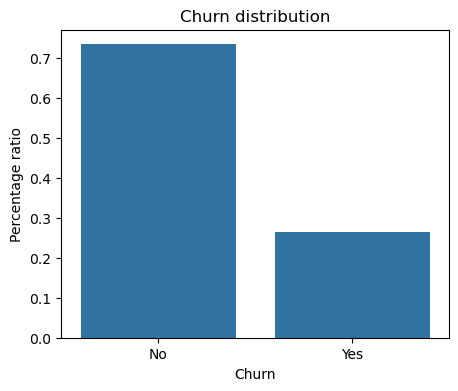

In [446]:
baseline = df.Churn.value_counts(normalize=True)
print(baseline)
plt.figure(figsize=(5,4))
sns.barplot(baseline)
plt.xlabel("Churn")
plt.ylabel("Percentage ratio")
plt.title("Churn distribution")
plt.show();

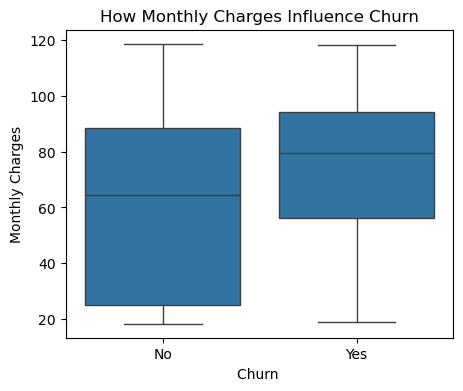

In [447]:
plt.figure(figsize=(5,4))
sns.boxplot(data= df, x='Churn', y='MonthlyCharges')
plt.xlabel("Churn ")
plt.ylabel("Monthly Charges")
plt.title("How Monthly Charges Influence Churn")
plt.savefig("monthly_charges_vs_churn.png", bbox_inches='tight', dpi=300);

In [448]:
#since the data is right skwed we fill the nan columns with median value of the column
skewness = df['TotalCharges'].skew()
print(skewness)
df['TotalCharges']= df['TotalCharges'].fillna(df['TotalCharges'].median())

0.961642499724251


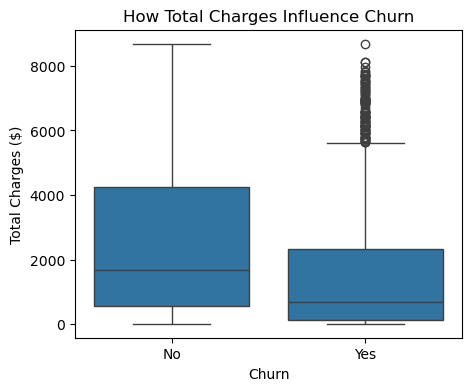

In [449]:
plt.figure(figsize=(5,4))
sns.boxplot(data= df, x='Churn', y='TotalCharges')
plt.xlabel("Churn")
plt.ylabel("Total Charges ($)")
plt.title("How Total Charges Influence Churn");

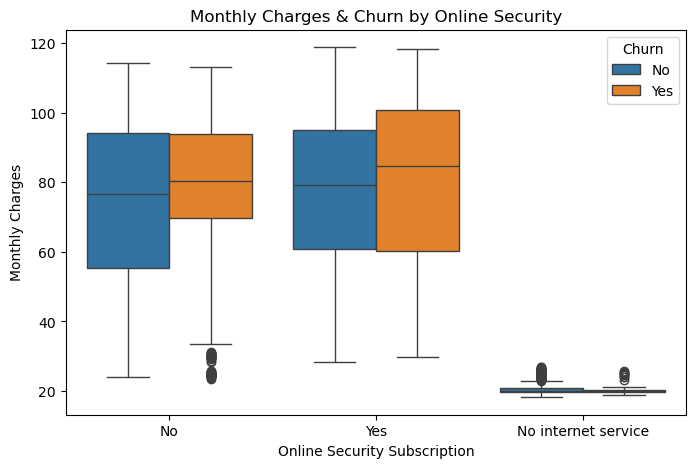

In [450]:
#Check if customers paying higher monthly charges but lacking OnlineSecurity churn more.
plt.figure(figsize=(8,5))
sns.boxplot(x="OnlineSecurity", y="MonthlyCharges", hue="Churn", data=df)
plt.title("Monthly Charges & Churn by Online Security")
plt.xlabel("Online Security Subscription")
plt.ylabel("Monthly Charges")
plt.show()

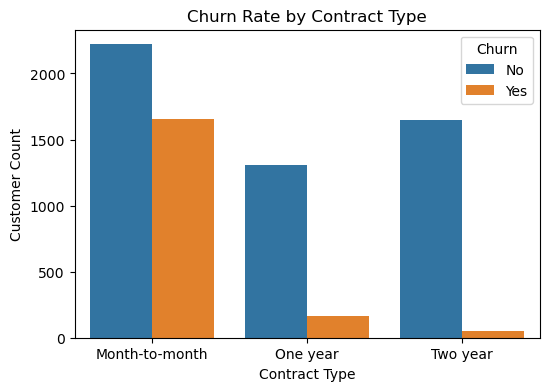

In [451]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.savefig("churn_by_contract.png", bbox_inches='tight', dpi=300)
plt.show();

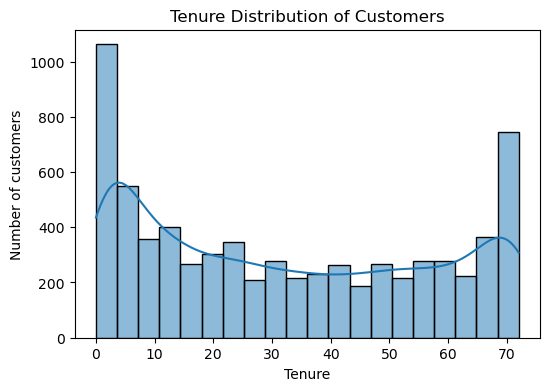

In [452]:
plt.figure(figsize=(6, 4))
sns.histplot(df['tenure'], bins=20, kde=True)
plt.title("Tenure Distribution of Customers")
plt.xlabel("Tenure")
plt.ylabel("Number of customers")
plt.show()

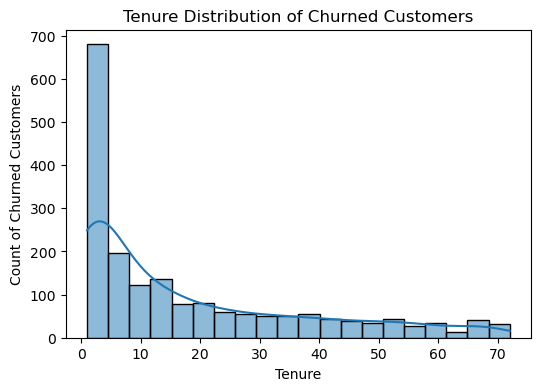

In [453]:
plt.figure(figsize=(6, 4))
sns.histplot(df[df['Churn']=='Yes']['tenure'], bins=20, kde=True)
plt.title("Tenure Distribution of Churned Customers")
plt.xlabel("Tenure")
plt.ylabel("Count of Churned Customers")
plt.savefig("tenure_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

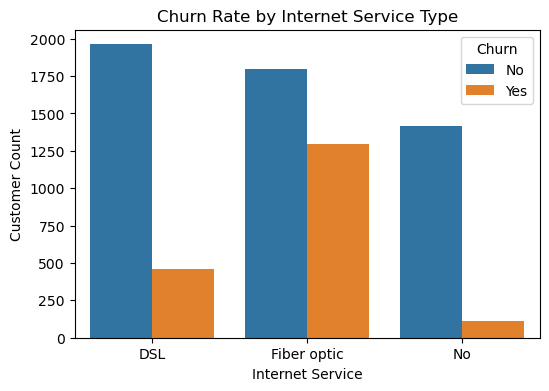

In [454]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.savefig("churn_by_internet_service.png", bbox_inches='tight', dpi=300)
plt.show()

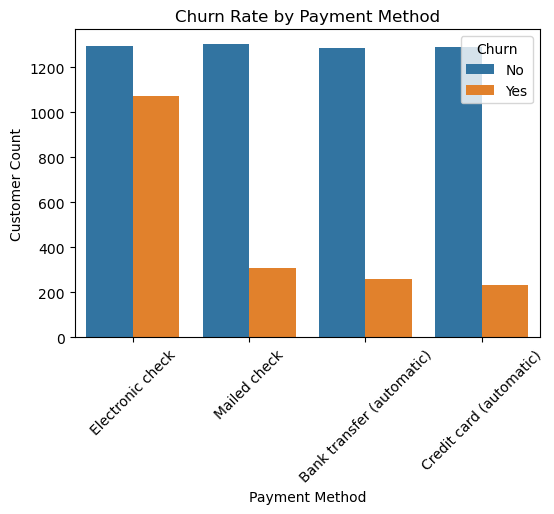

In [455]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.savefig("churn_by_payment_method.png", bbox_inches='tight', dpi=300)
plt.show()

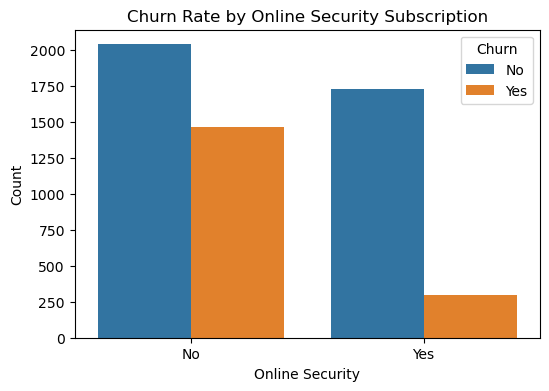

In [456]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="OnlineSecurity", hue="Churn", order=["No", "Yes"])
plt.title("Churn Rate by Online Security Subscription")
plt.xlabel("Online Security")
plt.ylabel("Count")
plt.savefig("churn_by_online_security.png", bbox_inches='tight', dpi=300)
plt.show()

<Figure size 1000x500 with 0 Axes>

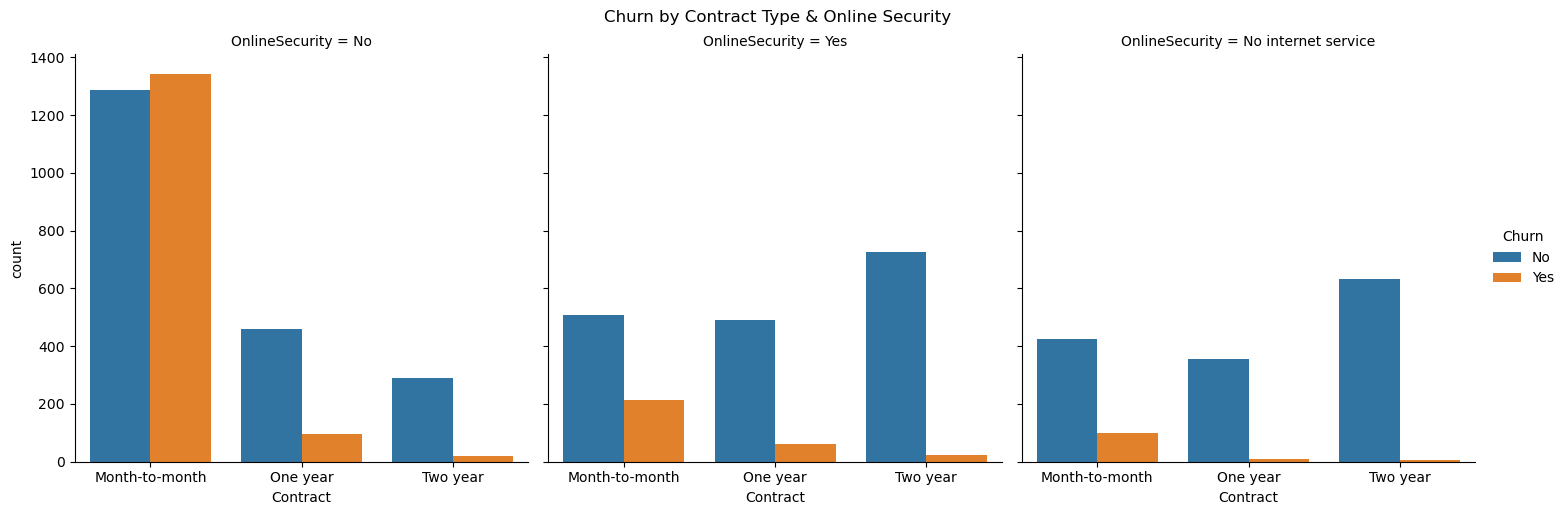

In [457]:
#Check if contract type influences churn for users with or without OnlineSecurity.
plt.figure(figsize=(10,5))
sns.catplot(x="Contract", hue="Churn", col="OnlineSecurity", kind="count", data=df)
plt.suptitle("Churn by Contract Type & Online Security", y=1.02)
plt.show();

In [458]:
def Countplot(df, column):
    plt.figure(figsize=(6,4))
    counts = df.groupby(['Churn'])[column].value_counts(normalize=True).reset_index(name="Percentage")
    sns.barplot(data=counts, x='Churn', y='Percentage', hue=column)
    plt.xlabel('Churn')
    plt.ylabel("Percentage")
    plt.legend(title=column)
    plt.title(f"Distribution of {column} by Churn")
    plt.show()


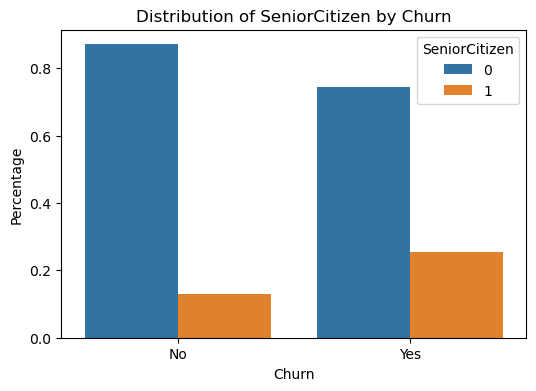

In [459]:
Countplot(df, 'SeniorCitizen')

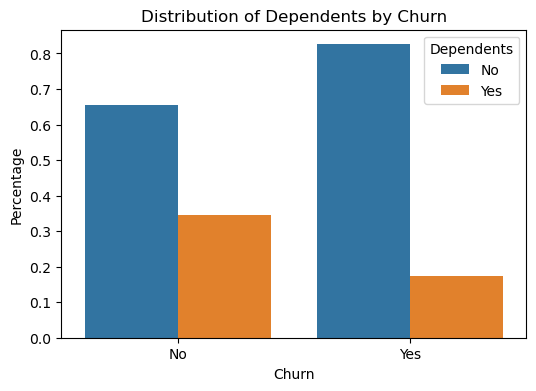

In [460]:
Countplot(df, 'Dependents')

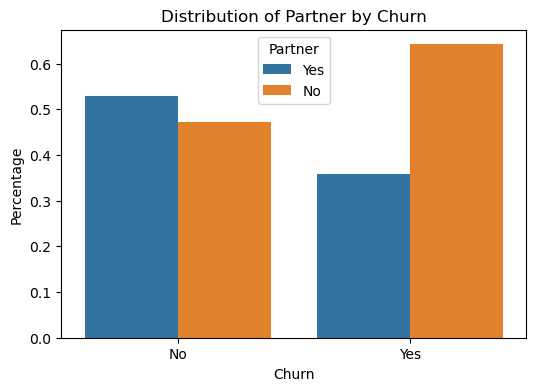

In [461]:
Countplot(df, 'Partner')

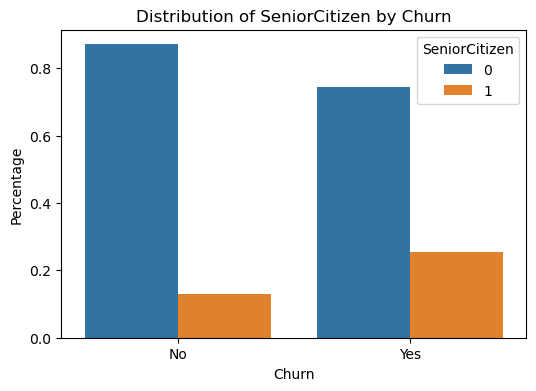

In [462]:
Countplot(df,'SeniorCitizen')

<Axes: >

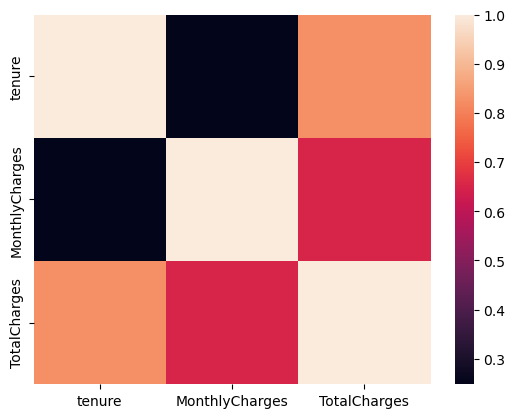

In [463]:
num = df.select_dtypes('number').columns
corr = df[num].corr().round(3)
sns.heatmap(corr)

In [464]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report
import shap


In [465]:
binary_features = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
df[binary_features] = df[binary_features].apply(lambda x: x.map({'Yes': 1, 'No': 0}))

In [466]:
ordinal_labels = ['Contract']

binary_labels = ['SeniorCitizen','Partner', 
          'Dependents', 'PhoneService', 
          'PaperlessBilling']

hot_encoded_lables = ['MultipleLines', 'InternetService',
               'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies','PaymentMethod']

scale_labels = ['MonthlyCharges', 'TotalCharges', 'tenure']

In [467]:
binary_transformer = OrdinalEncoder() 
hot_encoder_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
ordinal_transformer = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
scale_transformer = StandardScaler()

In [468]:
preprocessor = ColumnTransformer([
    ('binary_encoder', binary_transformer, binary_labels),
    ('one_hot_encoder', hot_encoder_transformer, hot_encoded_lables),
    ('ordinal_encoder',ordinal_transformer,ordinal_labels),
    ('scaler', scale_transformer, scale_labels)
    
])

In [469]:
X = df.drop(columns=['gender','Churn', 'customerID'])
y = df['Churn'].map({'Yes':1, 'No':0})

In [470]:
X

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85
1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50
2,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15
3,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75
4,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.50
7039,0,1,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90
7040,0,1,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45
7041,1,1,0,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.60


In [471]:
X_processed = preprocessor.fit_transform(X)

In [472]:
feature_name = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed, columns=feature_name)

In [473]:
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, random_state=42, test_size=0.2,stratify=y)

In [474]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [475]:
#model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
sgd = SGDClassifier(loss="log_loss", max_iter=1000, learning_rate="optimal", random_state=42)


In [476]:
rf_cross_score = cross_val_score(rf, X_train, y_train, cv=cv,scoring="accuracy").mean()
xgb_cross_score = cross_val_score(xgb, X_train, y_train, cv=cv,scoring="accuracy").mean()
sgd_cross_score = cross_val_score(sgd, X_train, y_train, cv=cv,scoring="accuracy").mean()

In [477]:
print(f"RandomForest Accuracy: {rf_cross_score:.4f}")
print(f"XGBoost Accuracy: {xgb_cross_score:.4f}")
print(f"SGDClassifier Accuracy: {sgd_cross_score:.4f}")

RandomForest Accuracy: 0.7929
XGBoost Accuracy: 0.7842
SGDClassifier Accuracy: 0.7984


### Results show that SGDClassifier (Gradient Descent) has the highest accuracy
#### fine-tune SGDClassifier using GridSearchCV to optimize its hyperparameters.

In [478]:
params = {
    'loss':['log_loss'],
    'alpha':[0.0001,0.001,0.01,0.1],
    'penalty':['l1'],
    'max_iter':[1000,2000,4000],
    'learning_rate':['optimal'],
    'eta0':[0.01,0.1,1]
    
}

In [479]:
model = GridSearchCV(sgd, params, cv=5, scoring='accuracy', n_jobs=-1)

In [480]:
model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SGDClassifier(loss='log_loss', random_state=42),
             n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1],
                         'eta0': [0.01, 0.1, 1], 'learning_rate': ['optimal'],
                         'loss': ['log_loss'], 'max_iter': [1000, 2000, 4000],
                         'penalty': ['l1']},
             scoring='accuracy')

In [481]:
best_model = model.best_estimator_
best_model

SGDClassifier(alpha=0.001, eta0=0.01, loss='log_loss', penalty='l1',
              random_state=42)

In [482]:
test_data_accuracy = best_model.score(X_test, y_test)
print(f'The Test accuracy is: {test_data_accuracy:.4f}')

The Test accuracy is: 0.7991


In [483]:
print(classification_report(y_test, best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [484]:
sgd_coef = best_model.coef_[0]
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': sgd_coef
}).sort_values(by="Coefficient", ascending=False)
feature_importance_df

,Feature,Coefficient
7,one_hot_encoder__InternetService_Fiber optic,0.735289
22,one_hot_encoder__PaymentMethod_Electronic check,0.371353
4,binary_encoder__PaperlessBilling,0.332560
18,one_hot_encoder__StreamingTV_Yes,0.214614
20,one_hot_encoder__StreamingMovies_Yes,0.209953
26,scaler__TotalCharges,0.198879
6,one_hot_encoder__MultipleLines_Yes,0.192795
0,binary_encoder__SeniorCitizen,0.119638
25,scaler__MonthlyCharges,0.083225
1,binary_encoder__Partner,0.000000


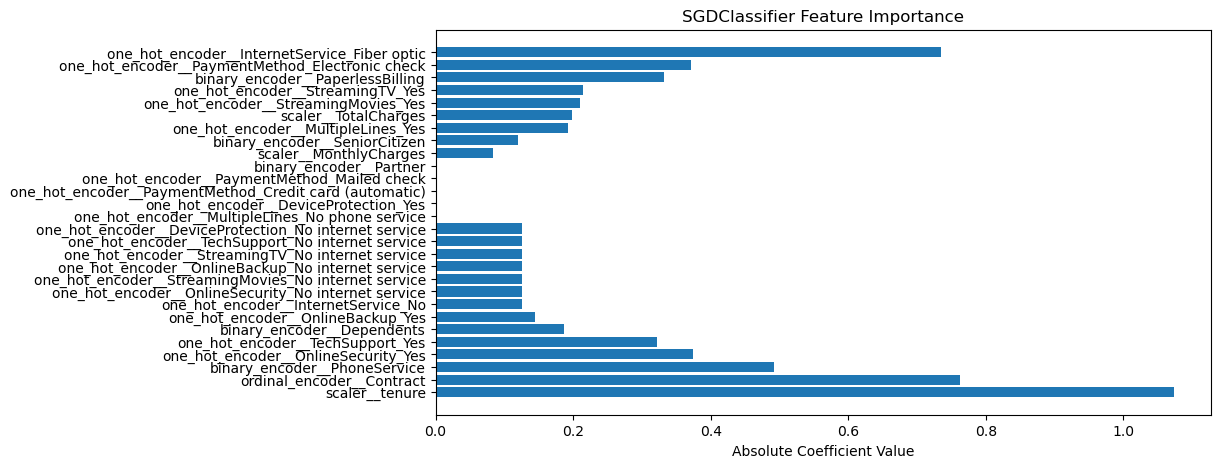

In [485]:
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], abs(feature_importance_df['Coefficient']))
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient Value")
plt.title("SGDClassifier Feature Importance")
plt.show()

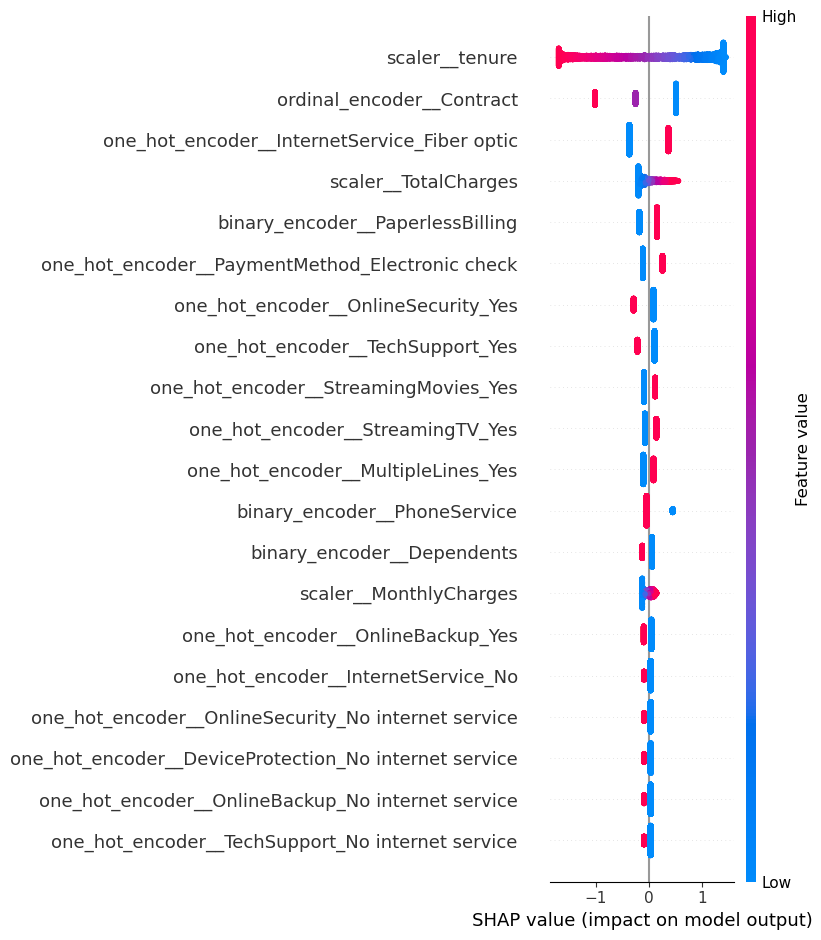

In [486]:
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)
shap.initjs()
# Ensure proper indexing and use Explanation object
shap_explainer = shap.Explanation(values=shap_values.values[0],  
                                  base_values=shap_values.base_values[0],  
                                  data=X_train.iloc[0])




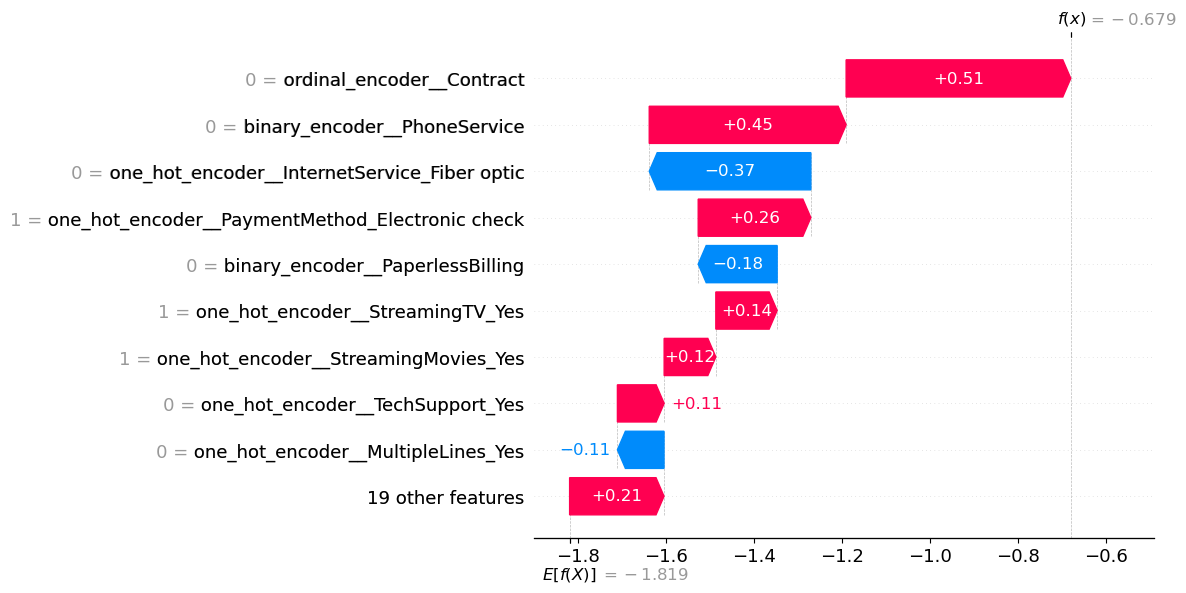

In [487]:
shap.plots.waterfall(shap_values[0])

In [489]:
import pickle